1401
1401
423
423
29
29


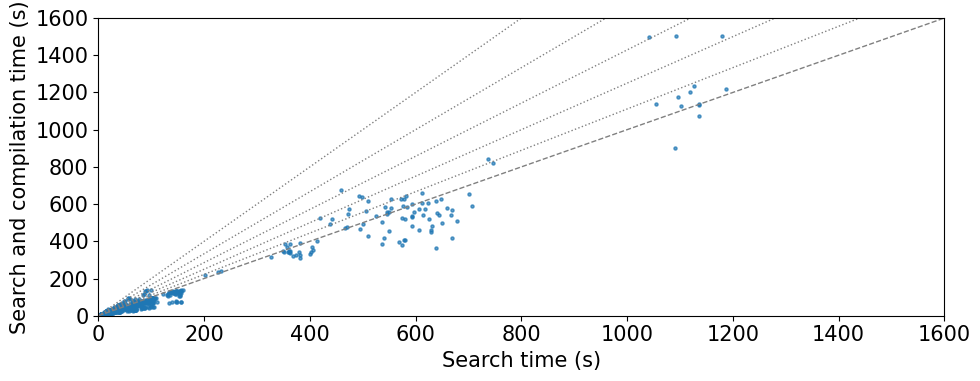

In [ ]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colorbar
import matplotlib.colors
import matplotlib.cm
import math

dataset = ['munin', 'pigs', 'water']
maximm = 0
fig = plt.figure(figsize=(10,4))

for d in dataset:
    file_search = "/experiments/data/outputs_LDS/bayesian_networks/"+d+"/search_time.csv"
    file_ub_lb = "/experiments/data/outputs_LDS/bayesian_networks/"+d+"/upper_and_lower_bound_time.csv"
    df_search = pd.read_csv(file_search)
    df_ub_lb = pd.read_csv(file_ub_lb)
    search_time = []
    ub_lb_time = []
    for i in range(len(df_search)):
        inst = df_search.iloc[i]['V1']
        time = int(df_search.iloc[i]['Stdout'].split()[-2])
        if time<1200:
            search_time.append(time)
            ub_lb_time.append(int(df_ub_lb[df_ub_lb['V1'].str.contains(inst)]['Stdout'].values[0].split()[-2]))
    print(len(search_time))
    print(len(ub_lb_time))
    maxi1 = np.array(search_time).max()
    maxi2 = np.array(ub_lb_time).max()
    maxi = maxi1 if maxi1>maxi2 else maxi2
    if maxi>maximm: maximm = maxi
    plt.scatter(search_time, ub_lb_time, s=20, color="tab:blue", marker='.', alpha=0.7)
maxi = math.ceil(maximm/100)*100
plt.xlabel("Search time (s)")
plt.ylabel("Search and compilation time (s)")
plt.plot([0, maxi], [0, maxi], color='gray', linestyle='--', linewidth=1)
plt.plot([0, maxi/2], [0, maxi], color='gray', linestyle=':', linewidth=1)
plt.plot([0, maxi*0.9], [0, maxi], color='gray', linestyle=':', linewidth=1)
plt.plot([0,0.8*maxi], [0, maxi], color='gray', linestyle=':', linewidth=1)
plt.plot([0,0.7*maxi], [0, maxi], color='gray', linestyle=':', linewidth=1)
plt.plot([0,0.6*maxi], [0, maxi], color='gray', linestyle=':', linewidth=1)
plt.xlim([0, maxi])
plt.ylim([0, maxi])
plt.rcParams.update({'font.size': 13})
fig.tight_layout()
#plt.show()
plt.savefig("/experiments/data/outputs_LDS/bayesian_networks/search_compil_time.png")